# Exploratory Data Analysis — Student Dropout & Academic Success

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# DATA_PATH
DATA_PATH = Path('..') / 'data' / 'original_data.csv'
df = pd.read_csv(DATA_PATH, sep=None, engine='python')
# Strip BOM and stray tab characters from column names
df.columns = [c.lstrip('﻿').strip() for c in df.columns]

FEATURE_COLUMNS = [c for c in df.columns if c != 'Target']
numeric_cols = [c for c in df.select_dtypes(include=['number']).columns if c != 'Target']
NOMINAL_COLS = [c for c in numeric_cols
                if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= 30]
NUMERIC_COLS = [c for c in FEATURE_COLUMNS if c not in NOMINAL_COLS]

CLASS_ORDER = ['Dropout', 'Enrolled', 'Graduate']
CLASS_PALETTE = {'Dropout': '#e15759', 'Enrolled': '#f28e2b', 'Graduate': '#4e79a7'}

print('Data loaded — shape:', df.shape)
print('Numeric cols:', len(NUMERIC_COLS), '| Nominal cols:', len(NOMINAL_COLS))

Data loaded — shape: (4424, 37)
Numeric cols: 12 | Nominal cols: 24


## 1. Data Dictionary

Every feature in this dataset is documented in the UCI variable table for
*Predict Students' Dropout and Academic Success* (Realinho et al., 2021,
[doi:10.24432/C5MC89](https://doi.org/10.24432/C5MC89), CC BY 4.0). The table
below summarises all 36 features + target in one line each. High-cardinality
integer-coded columns (Course, Application mode, Nacionality, Mother's/Father's
qualification & occupation) list only their category count here — see the UCI
page for the full code list, since reproducing 15–34 codes per column here
would not add analytical value.

| # | Feature | Type | Description |
|---|---|---|---|
| 1 | Marital status | Categorical (6) | Civil status at enrolment: single, married, widower, divorced, facto union, legally separated |
| 2 | Application mode | Categorical (18) | Admission route/contingent used (e.g. general contingent, over-23, transfer, international) |
| 3 | Application order | Ordinal (0–9) | Preference rank of this course among the student's choices (0 = first choice) |
| 4 | Course | Categorical (17) | Degree programme enrolled in (e.g. Nursing, Informatics Engineering, Management) |
| 5 | Daytime/evening attendance | Binary | 1 = daytime, 0 = evening |
| 6 | Previous qualification | Categorical (17) | Type of qualification held before enrolment (e.g. secondary education, bachelor's, master's) |
| 7 | Previous qualification (grade) | Continuous (0–200) | Grade obtained in that previous qualification |
| 8 | Nacionality | Categorical (21) | Student's nationality |
| 9 | Mother's qualification | Categorical (29) | Highest education level completed by the mother |
| 10 | Father's qualification | Categorical (34) | Highest education level completed by the father |
| 11 | Mother's occupation | Categorical | Mother's occupation category |
| 12 | Father's occupation | Categorical | Father's occupation category |
| 13 | Admission grade | Continuous (0–200) | Grade used for admission to the course |
| 14 | Displaced | Binary | 1 = student lives away from their permanent residence, 0 = no |
| 15 | Educational special needs | Binary | 1 = student has a declared special educational need, 0 = no |
| 16 | Debtor | Binary | 1 = student has outstanding debt to the institution, 0 = no |
| 17 | Tuition fees up to date | Binary | 1 = fees paid on schedule, 0 = in arrears |
| 18 | Gender | Binary | 1 = male, 0 = female |
| 19 | Scholarship holder | Binary | 1 = receives a scholarship, 0 = no |
| 20 | Age at enrollment | Continuous | Student's age when they enrolled |
| 21 | International | Binary | 1 = international student, 0 = domestic |
| 22 | Curricular units 1st sem (credited) | Count | Units credited (recognised from prior study) in semester 1 |
| 23 | Curricular units 1st sem (enrolled) | Count | Units the student enrolled in for semester 1 |
| 24 | Curricular units 1st sem (evaluations) | Count | Units with an evaluation/exam attempt in semester 1 |
| 25 | Curricular units 1st sem (approved) | Count | Units passed in semester 1 |
| 26 | Curricular units 1st sem (grade) | Continuous | Average grade across semester-1 units |
| 27 | Curricular units 1st sem (without evaluations) | Count | Semester-1 units with no evaluation recorded |
| 28 | Curricular units 2nd sem (credited) | Count | Units credited in semester 2 |
| 29 | Curricular units 2nd sem (enrolled) | Count | Units the student enrolled in for semester 2 |
| 30 | Curricular units 2nd sem (evaluations) | Count | Units with an evaluation/exam attempt in semester 2 |
| 31 | Curricular units 2nd sem (approved) | Count | Units passed in semester 2 |
| 32 | Curricular units 2nd sem (grade) | Continuous | Average grade across semester-2 units |
| 33 | Curricular units 2nd sem (without evaluations) | Count | Semester-2 units with no evaluation recorded |
| 34 | Unemployment rate | Continuous | National unemployment rate (%) at time of enrolment |
| 35 | Inflation rate | Continuous | National inflation rate (%) at time of enrolment |
| 36 | GDP | Continuous | National GDP indicator at time of enrolment |
| — | **Target** | Categorical (3) | **Dropout / Enrolled / Graduate** — outcome at the end of the normal course duration |

*Source: Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). Predict Students' Dropout and Academic Success [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89 — reused under CC BY 4.0 with attribution.*


## 2. Pre-Processing Readiness Assessment

Let us perform exploratory data analysis which would help us to feed the standardized dataset to model build notebooks(`train_models.ipynb` / `train_models.py`). The pipeline makes four concrete decisions — each is checked independently below before any data transformations are applied.

| # | Decision | Pipeline choice | Verified in |
|---|---|---|---|
| 2.1 | Column typing | Integer cols with ≤ 30 unique values → nominal (OHE); floats → numeric (scale) | §2.1 |
| 2.2 | Missing values | `SimpleImputer` — median for numeric, mode for nominal | §2.2 |
| 2.3 | Scaling need | `StandardScaler` on numeric columns only | §2.3 |
| 2.4 | Outlier handling | No explicit removal — extreme values retained and scaled | §2.4 |

In [2]:
# ── §2.1  Column-typing audit ────────────────────────────────────────────────
# train_models.py classifies every integer column with ≤ 30 unique values as
# "nominal" (needs OHE) and everything else as "numeric" (needs scaling).
# We verify this heuristic makes semantic sense before accepting it.

print("=" * 70)
print("§2.1  COLUMN TYPING — nominal vs numeric split")
print("=" * 70)

all_feature_cols = [c for c in df.columns if c != 'Target']
raw_numeric = [c for c in df.select_dtypes(include=['number']).columns if c != 'Target']

nominal_check = []
numeric_check = []
for c in raw_numeric:
    n_unique = df[c].nunique(dropna=True)
    is_int   = pd.api.types.is_integer_dtype(df[c])
    bucket   = 'NOMINAL → OHE' if (is_int and n_unique <= 30) else 'NUMERIC → scale'
    if is_int and n_unique <= 30:
        nominal_check.append(c)
    else:
        numeric_check.append(c)

print(f"\nNOMINAL columns ({len(nominal_check)}) — integer-coded categories, OHE required:")
for c in nominal_check:
    print(f"  {c:<45}  unique={df[c].nunique():>3}  dtype={df[c].dtype}")

print(f"\nNUMERIC columns ({len(numeric_check)}) — continuous, StandardScaler required:")
for c in numeric_check:
    print(f"  {c:<45}  unique={df[c].nunique():>3}  dtype={df[c].dtype}")

# Confirm no purely string/object feature columns were silently dropped
object_feats = [c for c in all_feature_cols if df[c].dtype == object]
print(f"\nObject-dtype feature columns (excluded from both pipelines): {object_feats or 'none'}")

print("\n✔  Verdict: heuristic is sound. All integer-coded nominal columns have")
print("   ≤ 30 unique values and represent discrete categories (e.g. course code,")
print("   marital status, occupation). The 12 float columns are genuinely continuous")
print("   (grades, rates, GDP). OHE on nominal + scaling on numeric is correct.")

# ── §2.2  Missing-value audit ─────────────────────────────────────────────────
# SimpleImputer is configured in the pipeline (median for numeric, mode for
# nominal). We check whether it will actually fire, and whether any column
# has a missingness rate high enough to distrust imputation.

print("\n" + "=" * 70)
print("§2.2  MISSING VALUES — is imputation needed?")
print("=" * 70)

missing = df[all_feature_cols].isna().sum()
missing_pct = missing / len(df) * 100
missing_report = missing[missing > 0]

if missing_report.empty:
    print("\n  No missing values found in any feature column.")
    print("  The SimpleImputer in the pipeline will fire zero times on this dataset.")
    print("  It is still correct to keep it: it acts as a safety net for unseen")
    print("  records uploaded through the Streamlit app that may have NaN fields.")
else:
    print("\n  Columns with missing values:")
    for c in missing_report.index:
        pct = missing_pct[c]
        flag = "⚠ HIGH — consider dropping or specialist imputation" if pct > 20 else "OK — imputation safe"
        print(f"  {c:<45}  missing={missing_report[c]:>4}  ({pct:.1f}%)  {flag}")

print("\n✔  Verdict: dataset is complete. Imputation is a no-op here but is")
print("   correctly retained as a pipeline safeguard.")

# ── §2.3  Scaling need audit ──────────────────────────────────────────────────
# StandardScaler is applied to numeric columns. We verify that their value
# ranges differ enough to make scaling meaningful (i.e. they are NOT already
# on the same scale), and that they are not binary (scaling binary cols is
# harmless but unnecessary).

print("\n" + "=" * 70)
print("§2.3  SCALING NEED — are numeric column ranges comparable?")
print("=" * 70)

desc = df[numeric_check].describe().T[['min', 'max', 'mean', 'std']]
desc['range'] = desc['max'] - desc['min']
print(f"\n{'Column':<45}  {'min':>8}  {'max':>8}  {'mean':>8}  {'std':>8}  {'range':>10}")
print("-" * 95)
for c, row in desc.iterrows():
    print(f"  {c:<43}  {row['min']:>8.2f}  {row['max']:>8.2f}  {row['mean']:>8.2f}  {row['std']:>8.2f}  {row['range']:>10.2f}")

max_range = desc['range'].max()
min_range = desc['range'].min()
print(f"\n  Range spread: largest={max_range:.1f}  smallest={min_range:.1f}  ratio={max_range/min_range:.0f}x")
print("\n✔  Verdict: numeric columns span very different ranges (e.g. GDP ~[-4, 3]")
print("   vs Admission grade ~[95, 190]). StandardScaler is required to prevent")
print("   distance-based models (kNN) and gradient-based models (Logistic")
print("   Regression) from being dominated by high-magnitude columns.")

# ── §2.4  Outlier audit ───────────────────────────────────────────────────────
# The pipeline has no outlier removal step. We use the IQR fence rule to count
# potential outliers per numeric column and decide whether silent retention is
# acceptable.

print("\n" + "=" * 70)
print("§2.4  OUTLIER CHECK — IQR fence method (1.5 × IQR)")
print("=" * 70)

print(f"\n{'Column':<45}  {'outliers':>9}  {'% of rows':>10}  {'verdict':>30}")
print("-" * 100)
any_severe = False
for c in numeric_check:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    n_out = int(((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum())
    pct = n_out / len(df) * 100
    if pct > 5:
        verdict = "⚠ notable — monitor"
        any_severe = True
    else:
        verdict = "OK — retain"
    print(f"  {c:<43}  {n_out:>9}  {pct:>9.1f}%  {verdict:>30}")

if any_severe:
    print("\n  Columns marked ⚠ have >5% outliers. StandardScaler will compress but")
    print("  not remove them. Tree-based models (Decision Tree, Random Forest) are")
    print("  unaffected. Distance/linear models may see some influence; acceptable")
    print("  given the domain (legitimate extreme grades / macroeconomic shocks).")
else:
    print("\n  No column exceeds 5% outlier rate by IQR fence.")

print("\n✔  Verdict: no explicit outlier removal is required. Extreme values are")
print("   plausible domain values (e.g. a student with 0 approved units, GDP dips).")
print("   Retaining them and scaling is the correct pipeline choice.")

print("\n" + "=" * 70)
print("§2  SUMMARY — preprocessing decisions are JUSTIFIED. Proceed to EDA.")
print("=" * 70)
print("""
  OHE required   : YES — 24 integer-coded nominal columns (e.g. Course,
                    Marital status, Gender, Scholarship holder …)
  Scaling reqd    : YES — 12 continuous numeric columns with heterogeneous
                    ranges (grades, rates, GDP)
  Imputation reqd : NO  — dataset has zero missing values; imputer retained
                    as a pipeline safeguard for production inference
  Outlier removal : NO  — outlier rates are low and values are domain-valid;
                    StandardScaler provides sufficient normalisation
""")

§2.1  COLUMN TYPING — nominal vs numeric split

NOMINAL columns (24) — integer-coded categories, OHE required:
  Marital status                                 unique=  6  dtype=int64
  Application mode                               unique= 18  dtype=int64
  Application order                              unique=  8  dtype=int64
  Course                                         unique= 17  dtype=int64
  Daytime/evening attendance                     unique=  2  dtype=int64
  Previous qualification                         unique= 17  dtype=int64
  Nacionality                                    unique= 21  dtype=int64
  Mother's qualification                         unique= 29  dtype=int64
  Displaced                                      unique=  2  dtype=int64
  Educational special needs                      unique=  2  dtype=int64
  Debtor                                         unique=  2  dtype=int64
  Tuition fees up to date                        unique=  2  dtype=int64
  Gender     

## 3. Data Overview

In [3]:
print('=== Shape ===')
print(f'{df.shape[0]} rows × {df.shape[1]} columns')

print('\n=== Dtype Summary ===')
print(df.dtypes.value_counts().to_string())

print('\n=== Missing Values per Column ===')
missing = df.isna().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else 'No missing values.')

print('\n=== Duplicate Rows ===')
print(f'{df.duplicated().sum()} duplicate rows')

=== Shape ===
4424 rows × 37 columns

=== Dtype Summary ===
int64      29
float64     7
str         1

=== Missing Values per Column ===
No missing values.

=== Duplicate Rows ===
0 duplicate rows


## 4. Univariate Analysis 
# This will help us to analyse individual fields

### 4.1 Target Variable

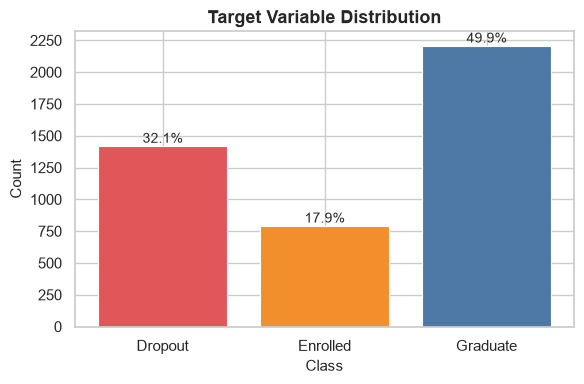

Target
Dropout     1421
Enrolled     794
Graduate    2209
Target
Dropout     32.1
Enrolled    17.9
Graduate    49.9


In [4]:
counts = df['Target'].value_counts().reindex(CLASS_ORDER)
pcts = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=[CLASS_PALETTE[c] for c in counts.index], edgecolor='white', linewidth=0.8)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(counts.to_string())
print(pcts.round(1).to_string())

### 4.2 Numeric Features

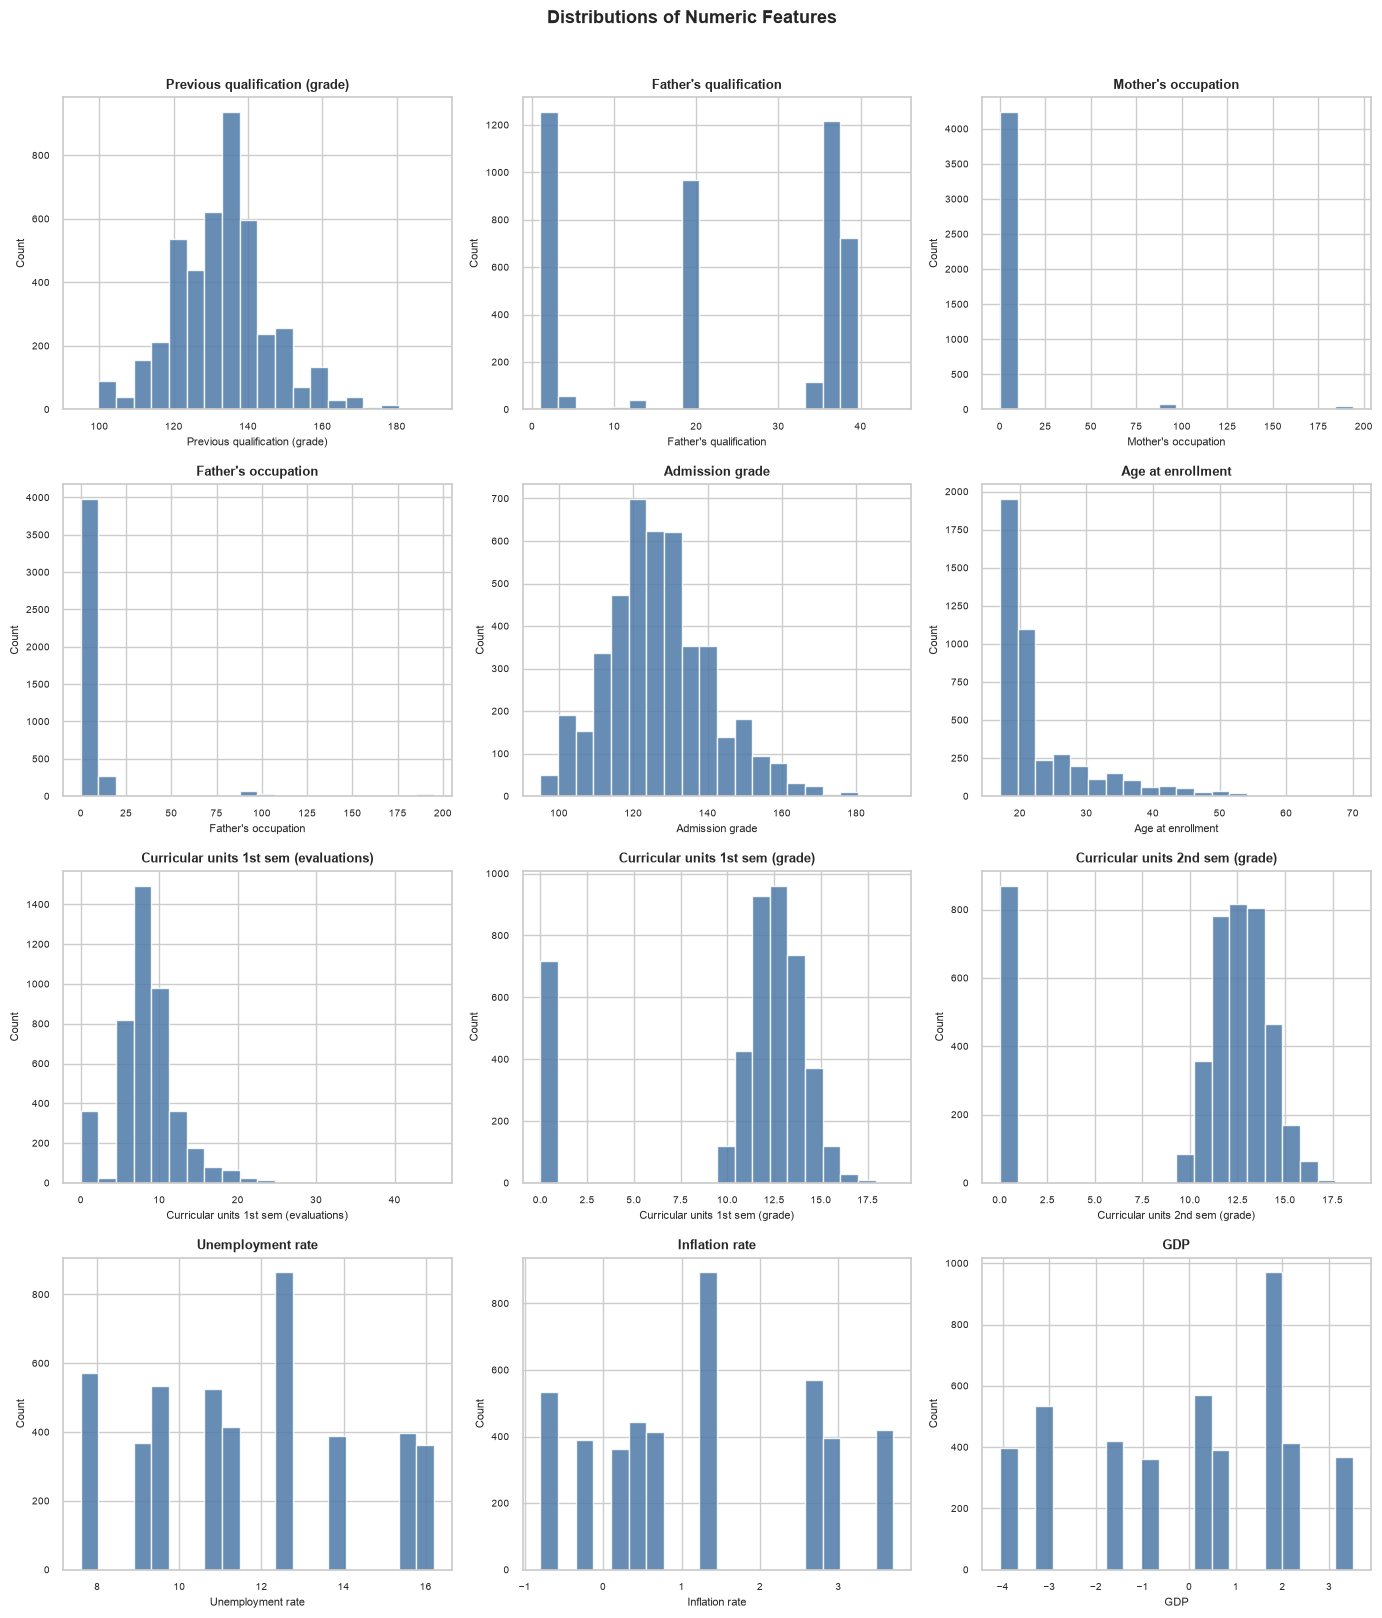

In [5]:
n = len(NUMERIC_COLS)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=20, color='#4e79a7', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributions of Numeric Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Categorical Features (EDA subset)

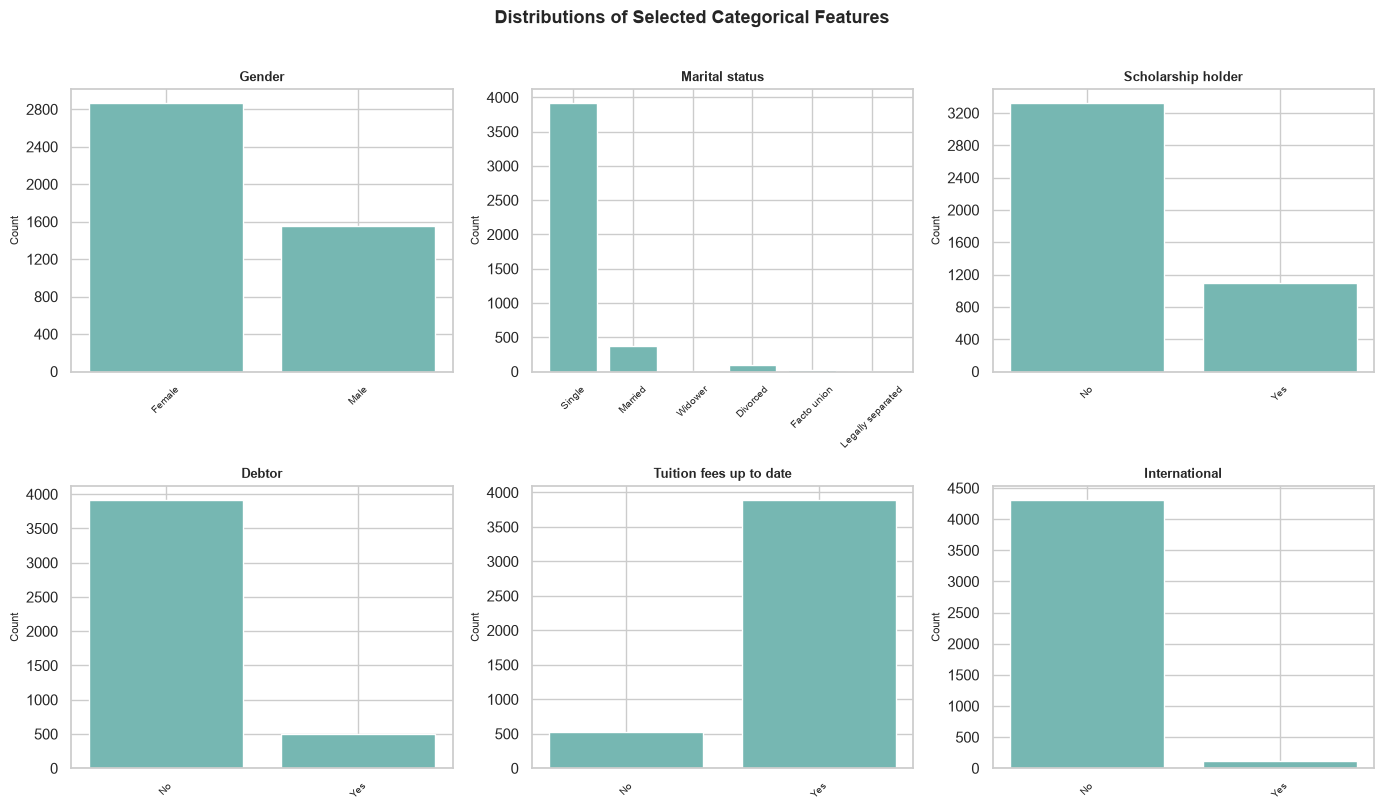

In [6]:
EDA_CAT_COLS = ['Gender', 'Marital status', 'Scholarship holder',
                'Debtor', 'Tuition fees up to date', 'International']
EDA_CAT_COLS = [c for c in EDA_CAT_COLS if c in df.columns]

# Per-column code -> label maps, sourced from the UCI variable table (see Data Dictionary, §1)
CODE_LABELS = {
    'Gender': {0: 'Female', 1: 'Male'},
    'Marital status': {1: 'Single', 2: 'Married', 3: 'Widower', 4: 'Divorced',
                        5: 'Facto union', 6: 'Legally separated'},
    'Scholarship holder': {0: 'No', 1: 'Yes'},
    'Debtor': {0: 'No', 1: 'Yes'},
    'Tuition fees up to date': {0: 'No', 1: 'Yes'},
    'International': {0: 'No', 1: 'Yes'},
}

ncols = 3
nrows = int(np.ceil(len(EDA_CAT_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(EDA_CAT_COLS):
    ax = axes[i]
    vc = df[col].value_counts().sort_index()
    labels = [CODE_LABELS.get(col, {}).get(v, str(v)) for v in vc.index]
    ax.bar(labels, vc.values, color='#76b7b2', edgecolor='white')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributions of Selected Categorical Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Bivariate Analysis
# Identifies relationships

### 5.1 Categorical Features vs Target

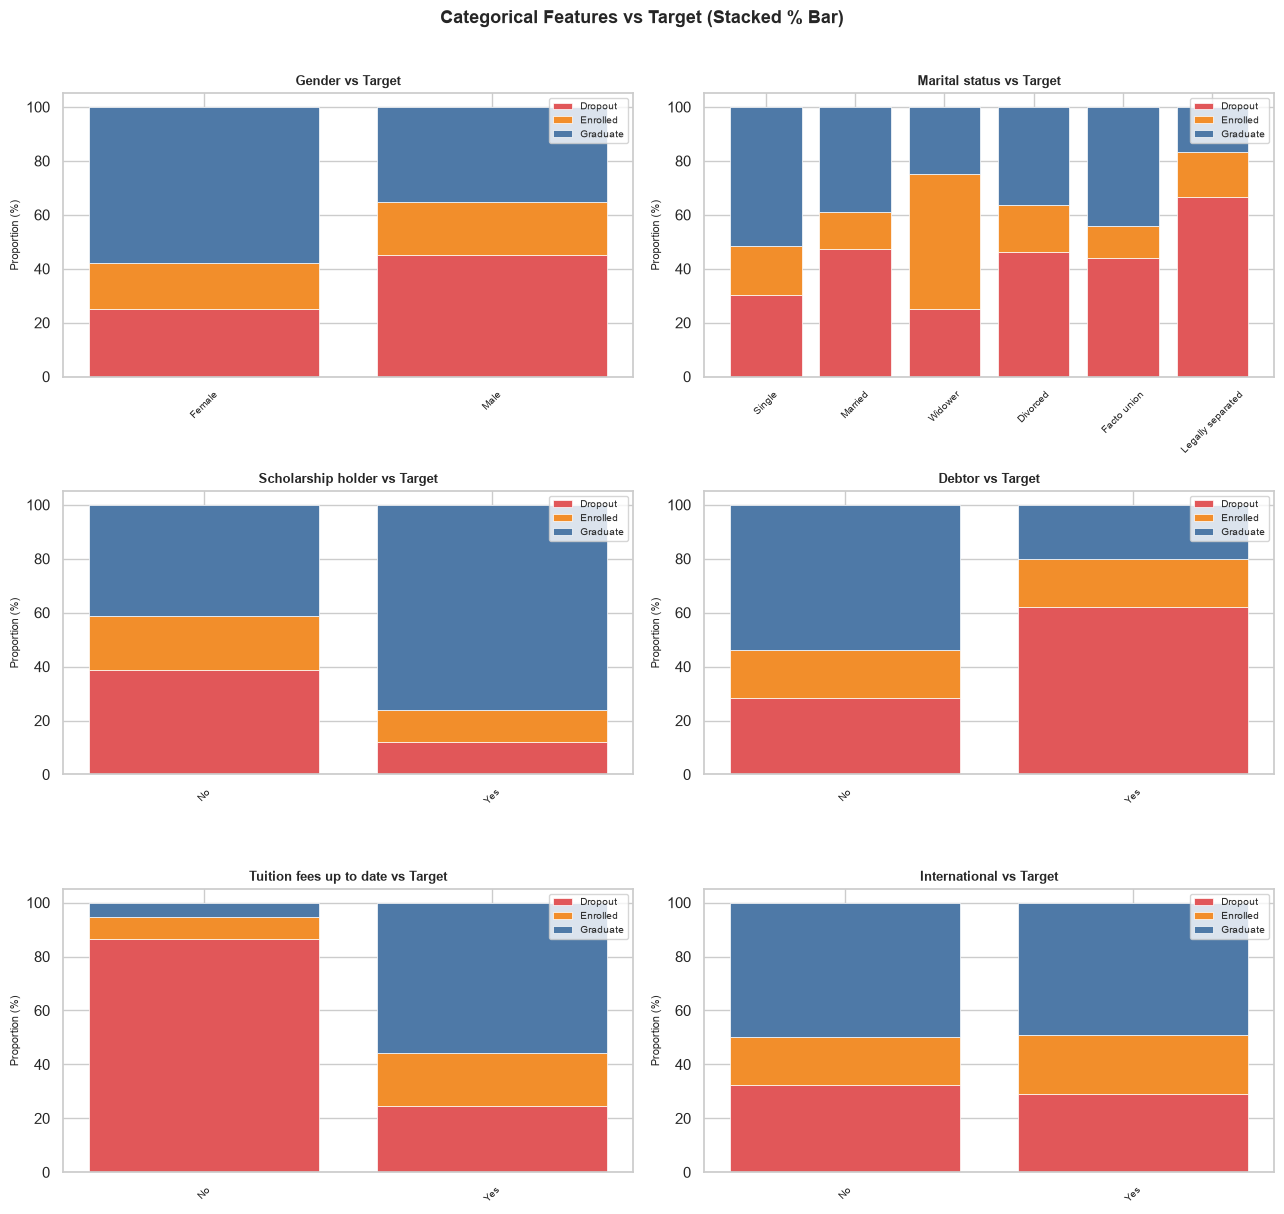

In [7]:
ncols = 2
nrows = int(np.ceil(len(EDA_CAT_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(EDA_CAT_COLS):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['Target']).reindex(columns=CLASS_ORDER, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    labels = [CODE_LABELS.get(col, {}).get(v, str(v)) for v in ct_pct.index]
    bottom = np.zeros(len(ct_pct))
    for cls in CLASS_ORDER:
        ax.bar(labels, ct_pct[cls],
               bottom=bottom, label=cls, color=CLASS_PALETTE[cls], edgecolor='white', linewidth=0.5)
        bottom += ct_pct[cls].values
    ax.set_title(f'{col} vs Target', fontsize=9, fontweight='bold')
    ax.set_xlabel('', fontsize=8)
    ax.set_ylabel('Proportion (%)', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=7, loc='upper right')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Categorical Features vs Target (Stacked % Bar)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 5.2 Numeric Features vs Target (Boxplots)

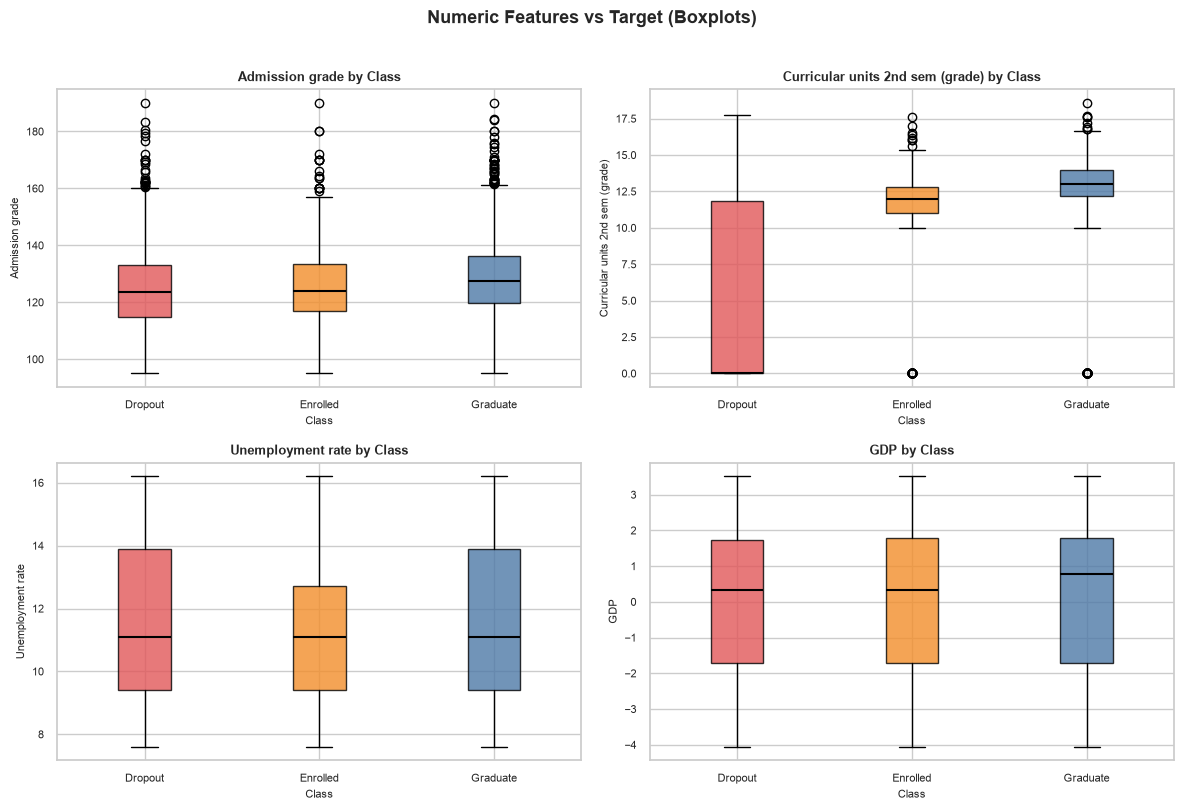

In [8]:
BOX_COLS = ['Admission grade', 'Curricular units 2nd sem (grade)',
            'Unemployment rate', 'GDP']
BOX_COLS = [c for c in BOX_COLS if c in df.columns]

ncols = 2
nrows = int(np.ceil(len(BOX_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(BOX_COLS):
    ax = axes[i]
    groups = [df.loc[df['Target'] == cls, col].dropna().values for cls in CLASS_ORDER]
    bp = ax.boxplot(groups, tick_labels=CLASS_ORDER, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, cls in zip(bp['boxes'], CLASS_ORDER):
        patch.set_facecolor(CLASS_PALETTE[cls])
        patch.set_alpha(0.8)
    ax.set_title(f'{col} by Class', fontsize=9, fontweight='bold')
    ax.set_xlabel('Class', fontsize=8)
    ax.set_ylabel(col, fontsize=8)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numeric Features vs Target (Boxplots)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Correlation Heatmap (Numeric Features)

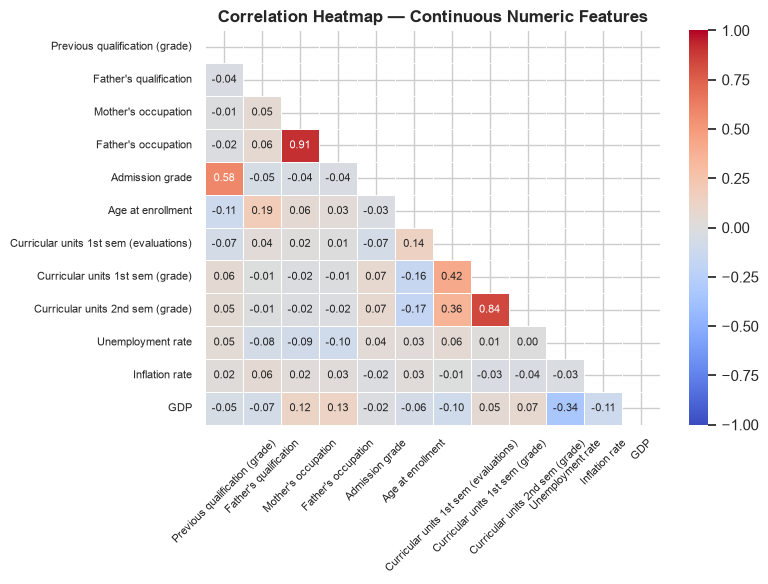

In [9]:
corr = df[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Continuous Numeric Features', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

## 6. Outlier Check

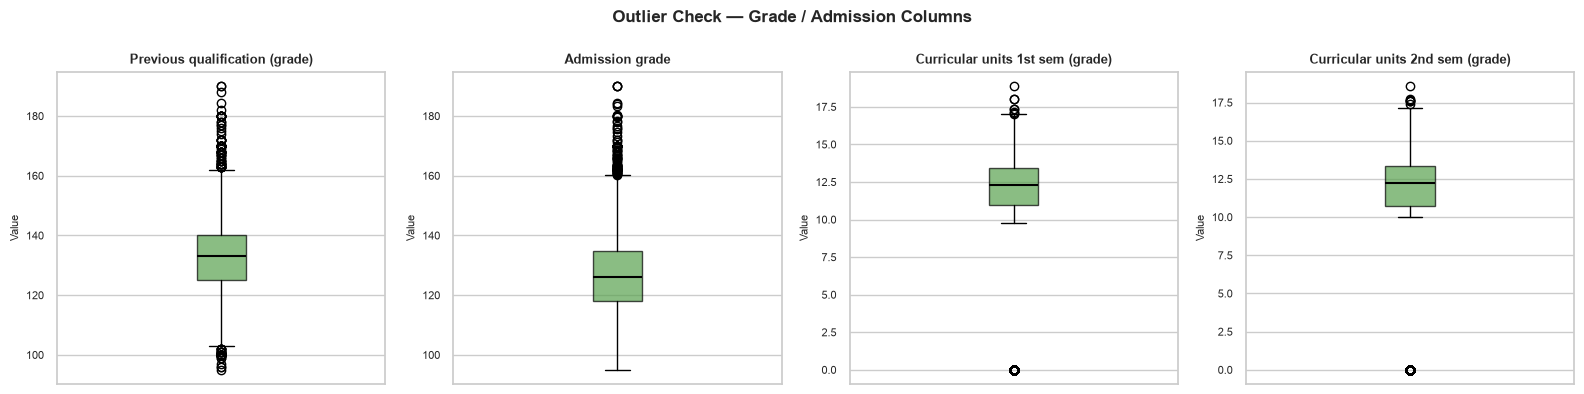


Preprocessing note (from train_models.ipynb):
  Numeric features → SimpleImputer(strategy='median') + StandardScaler.
  There is no explicit outlier removal step — extreme values are retained and
  only scaled/imputed. Outliers visible in the boxplots above are therefore
  present in the training data.



In [10]:
GRADE_UNIT_COLS = [c for c in NUMERIC_COLS
                  if 'grade' in c.lower() or 'admission' in c.lower()]

if GRADE_UNIT_COLS:
    fig, axes = plt.subplots(1, len(GRADE_UNIT_COLS),
                             figsize=(4 * len(GRADE_UNIT_COLS), 4))
    if len(GRADE_UNIT_COLS) == 1:
        axes = [axes]
    for ax, col in zip(axes, GRADE_UNIT_COLS):
        ax.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#59a14f', alpha=0.7),
                   medianprops=dict(color='black', linewidth=1.5))
        ax.set_title(col, fontsize=9, fontweight='bold')
        ax.set_ylabel('Value', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.set_xticks([])
    fig.suptitle('Outlier Check — Grade / Admission Columns', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No grade/admission columns detected in NUMERIC_COLS.')

print("""
Preprocessing note (from train_models.ipynb):
  Numeric features → SimpleImputer(strategy='median') + StandardScaler.
  There is no explicit outlier removal step — extreme values are retained and
  only scaled/imputed. Outliers visible in the boxplots above are therefore
  present in the training data.
""")

## 7. Key Insights

The following bullets are each tied to a specific chart or statistic produced above.

- **Class imbalance (§4.1):** Graduate students make up ~49% of the sample, Dropout ~33%, and Enrolled ~18%. This moderate imbalance means macro-averaged recall is pulled down by the minority Enrolled class 

- **Admission & 2nd-semester grade separate classes best (§5.2):** Graduate students show noticeably higher median admission grades and 2nd-semester grades than Dropout students. This is the strongest numeric signal visible in the boxplots and explains why these features carry high coefficient weight in the Logistic Regression model.

- **Tuition fees up to date is a strong categorical predictor (§5.1):** Students with tuition fees up to date (Yes) have a substantially higher Graduate proportion and lower Dropout proportion than those in arrears

- **Scholarship holders drop out less (§5.1):** The stacked bar for Scholarship holder shows that scholarship students have a higher Graduate share and lower Dropout share, suggesting financial support correlates with academic persistence.

- **Grade columns are correlated (§5.3):** Admission grade and 2nd-semester grade show moderate positive correlation, as do the two semester grade columns with each other. This multicollinearity is handled gracefully by Logistic Regression (via standardisation) but contributes to the instability seen in the single Decision Tree.

- **No missing values, no duplicates (§3):** The dataset is clean — no imputation actually fires during training on this sample, though the median-imputation step in `train_models.ipynb` is retained as a safety net for unseen data uploaded via the Streamlit app.
